# Cafe Sales Data (Data Cleaning & EDA)

May 2026
Jacqueline Molina

####

The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA).

## Initial Data Analysis

Dataset Columns: Transaction ID, Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location, Transaction Date

1. Clean Data (Fill in missing values, drop unecessary rows, delete duplicates)
2. Generate New (Needed) Columns from Clean Data (Separate Date into Month, Year, Day)
3. Remove Uneeded Columns
4. Generate Questions about the Data
5. Explore the Data (visualize it, draw correlations)
6. Generate Conclusions & Next Steps


In [403]:
## importing all needed libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [404]:
# read data in to notebook
url = 'dirty_cafe_sales.csv'
df = pd.read_csv(url)
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [405]:
df.shape

(10000, 8)

In [406]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [407]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


##

Check all columns for missing values and count the number of missing values. Fill in missing data. Improve data readability (Fix Data Types, Simplify Dates).

In [408]:
## Checking all 
missing_data = df.isnull()
for col in missing_data.columns.values.tolist():
    print(missing_data[col].value_counts())
    print('')

Transaction ID
False    10000
Name: count, dtype: int64

Item
False    9667
True      333
Name: count, dtype: int64

Quantity
False    9862
True      138
Name: count, dtype: int64

Price Per Unit
False    9821
True      179
Name: count, dtype: int64

Total Spent
False    9827
True      173
Name: count, dtype: int64

Payment Method
False    7421
True     2579
Name: count, dtype: int64

Location
False    6735
True     3265
Name: count, dtype: int64

Transaction Date
False    9841
True      159
Name: count, dtype: int64



##

### Cleaning 'Item', 'Quantity', 'Price Per Unit', 'Total Spent' Columns

In [409]:
df['Item'].value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64

In [410]:
## Item, Quantity, Price Per Unit, Total Spent are all interconnected

In [411]:
df.replace(['ERROR', 'UNKNOWN'], np.nan, inplace = True) ## replace all ERR/UNK values with NaN vals
df[['Quantity', 'Price Per Unit', 'Total Spent']] = df[['Quantity', 'Price Per Unit', 'Total Spent']].astype(np.float64) ## convert to float

In [412]:
## Quantity can be caluclated by dividing Total Spent by Price Per Unit
df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])
## Price Per Unit can be caluclated by dividing Total Spent by Quantity
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])
## Total Spent can be caluclated by multiplying Quantity by Price Per Unit
df['Total Spent'] = df['Total Spent'].fillna(df['Quantity'] * df['Price Per Unit'])

## fill in any values not able to be calculated with NaN

In [413]:
df[['Item', 'Price Per Unit']].value_counts()

Item      Price Per Unit
Juice     3.0               1170
Coffee    2.0               1163
Salad     5.0               1146
Cake      3.0               1135
Sandwich  4.0               1126
Smoothie  4.0               1091
Cookie    1.0               1086
Tea       1.5               1082
Name: count, dtype: int64

In [414]:
priceMap = {
    2.0 : 'Coffee',
    1.5 : 'Tea', 
    5.0 : 'Salad', 
    1.0 : 'Cookie'
}
## replace any NaN values in Item by looking at the Price Per Unit Col
replace = df['Price Per Unit'].map(priceMap)
df['Item'] = df['Item'].fillna(replace)

In [415]:
df['Item'].isnull().sum()

np.int64(480)

In [416]:
## Items priced at $3 and $4

In [417]:
three = ['Cake', 'Juice']
findThrees = ((df['Item'].isnull()) & (df['Price Per Unit'] == 3))
count = findThrees.sum()

# replace all missing items 50/50 split
if count > 0:
        df.loc[findThrees, 'Item'] = np.random.choice(three, size = count, p = [0.5, 0.5])   

In [418]:
four = ['Sandwich', 'Smoothie']
findFours = ((df['Item'].isnull()) & (df['Price Per Unit'] == 4))
count = findFours.sum()

# replace all missing items 50/50 split
if count > 0:
        df.loc[findFours, 'Item'] = np.random.choice(four, size = count, p = [0.5, 0.5])   

### Checking Missing Values Again

In [419]:
df['Item'].isnull().sum()

np.int64(6)

In [420]:
df['Quantity'].isnull().sum()

np.int64(38)

In [421]:
df['Price Per Unit'].isnull().sum()

np.int64(38)

In [422]:
df['Total Spent'].isnull().sum()

np.int64(40)

In [423]:
dfItems = df[df['Item'].isnull()]
dfItems
## cannot figure out original item from missing data (drop rows)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1761,TXN_3611851,NaN,4.0,NaN,NaN,Credit Card,NaN,2023-02-09
2289,TXN_7524977,NaN,4.0,NaN,NaN,NaN,NaN,2023-12-09
3779,TXN_7376255,NaN,NaN,NaN,25.0,NaN,In-store,2023-05-27
4152,TXN_9646000,NaN,2.0,NaN,NaN,NaN,In-store,2023-12-14
7597,TXN_1082717,NaN,NaN,NaN,9.0,Digital Wallet,In-store,2023-12-13
9819,TXN_1208561,NaN,NaN,NaN,20.0,Credit Card,NaN,2023-08-19


In [424]:
df = df.dropna(subset='Item') ## drop Item null rows

### Cleaning 'Price Per Unit' Column

In [425]:
dfP = df[df['Price Per Unit'].isnull()]
dfP.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
65,TXN_4987129,Sandwich,3.0,NaN,NaN,NaN,In-store,2023-10-20
629,TXN_9289174,Cake,NaN,NaN,12.0,Digital Wallet,In-store,2023-12-30
912,TXN_1575608,Sandwich,NaN,NaN,20.0,NaN,Takeaway,2023-01-05
1008,TXN_7225428,Tea,NaN,NaN,3.0,Credit Card,Takeaway,2023-03-07
1436,TXN_7590801,Tea,NaN,NaN,6.0,Cash,Takeaway,NaN


In [426]:
ItemMap = {
    'Juice': 3.0,
    'Coffee': 2.0,
    'Salad': 5.0,
    'Cake': 3.0,
    'Sandwich': 4.0,
    'Smoothie': 4.0,
    'Cookie': 1.0,
    'Tea': 1.5
}
## If Item is not null, map the Price Per Unit
replace = df['Item'].map(ItemMap)
df['Price Per Unit'] = df['Price Per Unit'].fillna(replace)

In [427]:
df['Price Per Unit'].isnull().sum()

np.int64(0)

### Cleaning 'Quantity' Column

In [428]:
dfQ = df[df['Quantity'].isnull()]
dfQ.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
236,TXN_8562645,Salad,NaN,5.0,NaN,NaN,In-store,2023-05-18
278,TXN_3229409,Juice,NaN,3.0,NaN,Cash,Takeaway,2023-04-15
629,TXN_9289174,Cake,NaN,3.0,12.0,Digital Wallet,In-store,2023-12-30
641,TXN_2962976,Juice,NaN,3.0,NaN,NaN,NaN,2023-03-17
738,TXN_8696094,Sandwich,NaN,4.0,NaN,NaN,Takeaway,2023-05-14


In [429]:
## recalculate in case Item and Price Per Unit were filled in the cells before
df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])

In [430]:
df['Quantity'].isnull().sum()

np.int64(20)

In [431]:
# nothig left to calculate, drop remaining missing rows
df = df.dropna(subset='Quantity')

### Cleaning 'Total Spent' Column

In [432]:
dfT = df[df['Total Spent'].isnull()]
dfT.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
65,TXN_4987129,Sandwich,3.0,4.0,NaN,NaN,In-store,2023-10-20
1674,TXN_9367492,Tea,2.0,1.5,NaN,Cash,In-store,2023-06-19
2229,TXN_8498613,Sandwich,2.0,4.0,NaN,NaN,NaN,2023-11-08
2585,TXN_1259340,Tea,3.0,1.5,NaN,Digital Wallet,NaN,2023-02-24
3162,TXN_3577949,Cake,3.0,3.0,NaN,NaN,Takeaway,2023-04-25


In [433]:
## re-calculate Total Spent from recently filled in data
df['Total Spent'] = df['Total Spent'].fillna(df['Quantity'] * df['Price Per Unit'])

In [434]:
df['Total Spent'].isnull().sum()

np.int64(0)

### Cleaning 'Payment Method' Column

In [435]:
## remove UNK/ERR from Payment Method
df = df[~df['Payment Method'].isin(['UNKNOWN','ERROR'])]
df['Payment Method'].value_counts()

Payment Method
Digital Wallet    2284
Credit Card       2268
Cash              2254
Name: count, dtype: int64

In [436]:
paymentFreq = df['Payment Method'].value_counts().idxmax()
paymentFreq

'Digital Wallet'

In [437]:
## replace null values with the most frequent value
df['Payment Method'] = df['Payment Method'].replace(np.nan, paymentFreq)
df['Payment Method'].isnull().sum()

np.int64(0)

### Cleaning 'Location' Column

In [438]:
## remove UNK/ERR from Location
df = df[~df['Location'].isin(['UNKNOWN','ERROR'])]
df['Location'].value_counts()

Location
Takeaway    3016
In-store    3006
Name: count, dtype: int64

In [439]:
locFreq = df['Location'].value_counts().idxmax()
locFreq

'Takeaway'

In [440]:
## replace null values with the most frequent value
df['Location'] = df['Location'].replace(np.nan, locFreq)
df['Location'].isnull().sum()

np.int64(0)

### Cleaning 'Transaction Date' Column

In [248]:
df = df[~df['Transaction Date'].isin(['UNKNOWN','ERROR'])]
df['Transaction Date'].value_counts()

Transaction Date
2023-02-06    40
2023-06-16    40
2023-07-21    39
2023-09-21    39
2023-07-24    39
              ..
2023-04-27    15
2023-11-24    15
2023-03-11    14
2023-02-17    14
2023-07-22    14
Name: count, Length: 365, dtype: int64

In [441]:
df['Transaction Date'].isnull().sum()

np.int64(460)

In [443]:
df = df.dropna(subset='Transaction Date')

In [444]:
df['Transaction Date'].isnull().sum()

np.int64(0)

In [445]:
df.shape

(9514, 8)

### Removing Duplicate Rows

In [446]:
duplicate_rows = df[df.duplicated()]
duplicate_rows

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


### Final Fixes to Clean Data

In [447]:
## separate date to year, month, day columns
## drop transaction ID (since its guaranteed to always be unique and its useless to us)

In [448]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [449]:
df.shape

(9514, 8)

In [450]:
df = df.drop(columns='Transaction ID')

In [451]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Month'] = df['Transaction Date'].dt.month
df['Day'] = df['Transaction Date'].dt.day
df['Year'] = df['Transaction Date'].dt.year

In [452]:
df.head()
## final look at clean dataset

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Day,Year
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,9,8,2023
1,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,5,16,2023
2,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,7,19,2023
3,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27,4,27,2023
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,6,11,2023


In [453]:
df.shape

(9514, 10)

In [454]:
##removed about ~500 rows of data through cleaning

##

## Exploratory Data Analysis

Initial Questions:
- Most popular item on the menu?
- Total revenue/sales per item?
- Revenue generated by DateTime(Month)?
- Most popular days of the week (sales)?
- Average spending amount per transaction per customer? Per Month?
- Do customers prefer eating in store or takeout?

##

In [455]:
## check correlations between numeric columns
correlations = df[['Quantity','Price Per Unit','Total Spent', 'Transaction Date']].corr()
correlations

,Quantity,Price Per Unit,Total Spent,Transaction Date
Quantity,1.000000,0.006676,0.704489,-0.004218
Price Per Unit,0.006676,1.000000,0.645986,-0.013634
Total Spent,0.704489,0.645986,1.000000,-0.007267
Transaction Date,-0.004218,-0.013634,-0.007267,1.000000


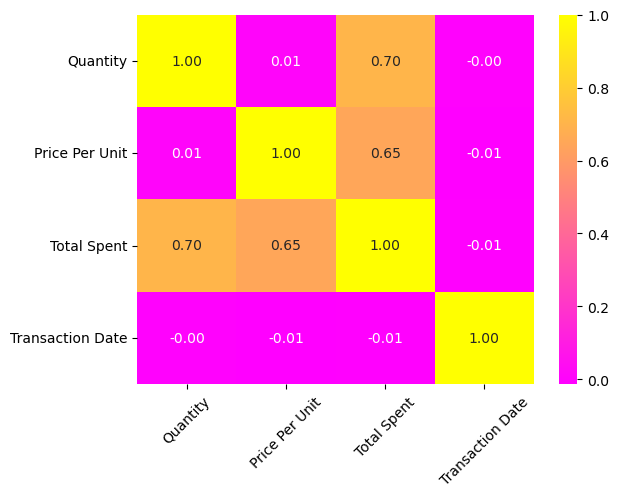

In [456]:
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='spring')
plt.xticks(rotation=45)
plt.show()

Total Spent and Quantity have a strong correlation of 0.7/1.0 <br>
Total Spent and Price Per Unit have a relatively strong correlation of 0.65/1.0

#### Most Popular Menu Item (Total)

In [457]:
## QUANTITY of items sold (not revenue)
numberOfItemsSold_df = df.groupby('Item')['Quantity'].sum().reset_index()
numberOfItemsSold_df

,Item,Quantity
0,Cake,3655.0
1,Coffee,3766.0
2,Cookie,3427.0
3,Juice,3681.0
4,Salad,3644.0
5,Sandwich,3567.0
6,Smoothie,3563.0
7,Tea,3441.0


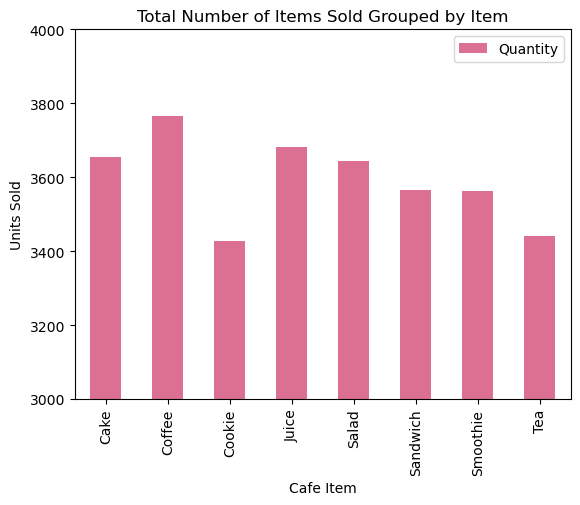

In [466]:
numberOfItemsSold_df.plot(kind='bar', x='Item',y='Quantity',color='palevioletred')
plt.xlabel('Cafe Item')
plt.ylabel('Units Sold')
plt.title('Total Number of Items Sold Grouped by Item')
plt.ylim(3000, 4000)
plt.show()

Coffee, Juice, and Cake are the top three performers in this cafe. <br> Smoothie, Tea, and Cookie are the bottom three performers in this cafe.


#### Total Revenue Generated by Each Item

In [467]:
## REVENUE generated from each item 
revenueOfItems_df = df.groupby('Item')['Total Spent'].sum().reset_index()
revenueOfItems_df

,Item,Total Spent
0,Cake,10965.0
1,Coffee,7532.0
2,Cookie,3427.0
3,Juice,11043.0
4,Salad,18220.0
5,Sandwich,14268.0
6,Smoothie,14252.0
7,Tea,5161.5


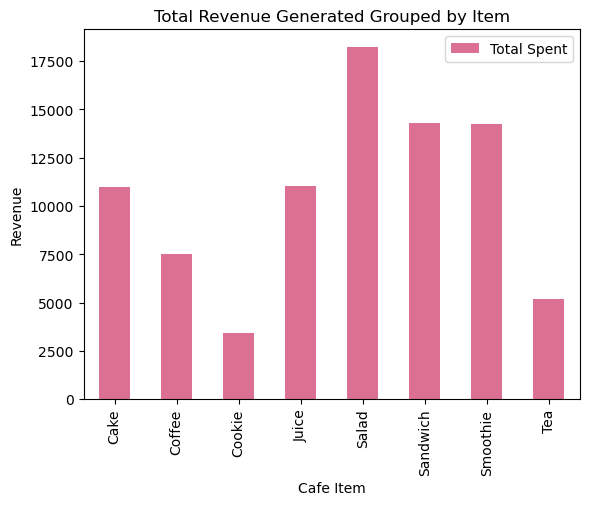

In [468]:
revenueOfItems_df.plot(kind='bar', x='Item',y='Total Spent',color='palevioletred')
plt.xlabel('Cafe Item')
plt.ylabel('Revenue')
plt.title('Total Revenue Generated Grouped by Item')
plt.show()

Salad, Sandwich, Smoothie generated the most revenue. <br>
Coffee, Tea, Cookie generated the least revenue.

##

Coffee and Juice are the top preforming items and yet, are not the top generators of revenue.
Tea and Cookie are both in the bottom three for both quantity of sales and generation of revenue.
Sandwich and Smoothie are likely accurately priced for the revenue generated.

#### Revenue Generated by Month

In [469]:
revenueMonth = df.groupby('Month')['Total Spent'].sum().reset_index()
revenueMonth['Month Names'] = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
revenueMonth

,Month,Total Spent,Month Names
0,1,7254.0,Jan
1,2,6644.0,Feb
2,3,7216.0,Mar
3,4,7179.0,Apr
4,5,6932.5,May
5,6,7353.0,June
6,7,6877.5,Jul
7,8,7092.5,Aug
8,9,6871.0,Sept
9,10,7314.0,Oct


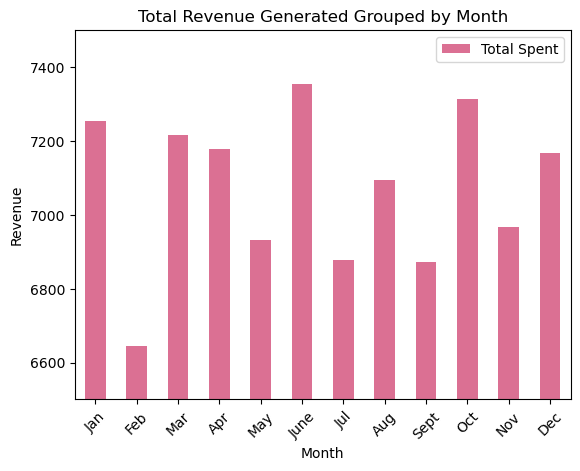

In [476]:
revenueMonth.plot(kind='bar', x='Month Names',y='Total Spent',color='palevioletred')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Total Revenue Generated Grouped by Month')
plt.ylim(6500, 7500)
plt.xticks(rotation=45)
plt.show()

June was the top preforming month. February was the worst performing month.

In [477]:
## pivot table of items sold per month per item
monthItem_cross = pd.crosstab(df['Month'], df['Item'])
monthItem_cross

Item,Cake,Coffee,Cookie,Juice,Salad,Sandwich,Smoothie,Tea
Month,,,,,,,,
1,104,96,97,109,113,116,78,102
2,88,93,81,98,97,82,94,93
3,112,115,104,110,102,100,88,95
4,101,97,83,102,108,92,102,86
5,93,96,93,105,95,106,99,85
6,96,110,97,105,108,99,108,94
7,97,102,108,80,111,103,94,94
8,96,104,90,97,106,104,93,111
9,109,92,99,99,84,100,101,102


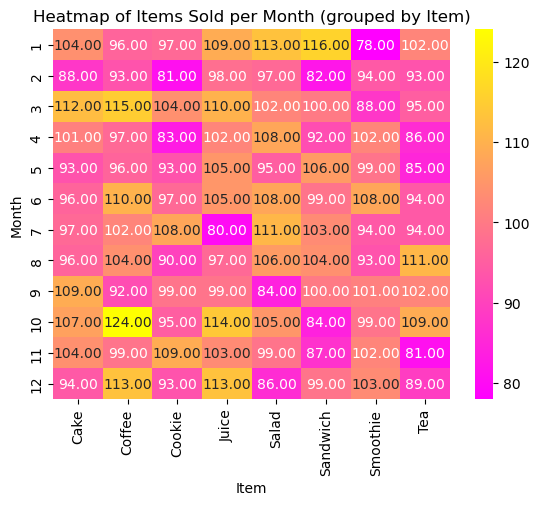

In [513]:
sns.heatmap(monthItem_cross, annot=True, fmt='.2f', cmap='spring')
plt.xticks(rotation=90)
plt.title('Heatmap of Items Sold per Month (grouped by Item)')
plt.show()

<b>Top 5 months per item (Over 100 Items Sold)</b><br>
Cake: Mar, Sept, Oct, Jan/Nov <br>
Coffee: Oct, Mar, Dec, Jun, Aug <br>
Cookie: Nov, Jun, Mar <br>
Juice: Oct, Dec, Mar, Jan, May/Jun <br>
Salad: Jan, Jul, Jun, Apr, Aug <br>
Sandwich: Jan, May, Aug, Jul, Mar/Sept <br>
Smoothie: June, Dec, Nov, Apr, Sept <br>
Tea: Aug, Oct, Jan, Sept

In [479]:
## Analyze the top performing month
juneRevenue = df[df['Month']==6]
juneRevenue = juneRevenue.groupby('Day')['Total Spent'].sum().reset_index()
juneRevenue.head(6)

,Day,Total Spent
0,1,322.0
1,2,190.5
2,3,189.0
3,4,156.0
4,5,183.5
5,6,355.5


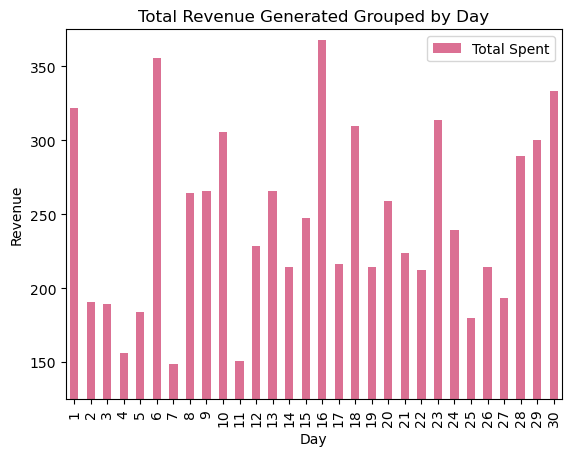

In [488]:
juneRevenue.plot(kind='bar', x='Day',y='Total Spent',color='palevioletred')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.title('Total Revenue Generated Grouped by Day')
plt.ylim(125,375)
plt.xticks(rotation=90)
plt.show()

In [484]:
## analyze the top performing day (June 16)
june = df[df['Month']==6]
popularJune = june[june['Day']==16]
groupedPopular = popularJune.groupby('Item')['Total Spent'].sum().reset_index()
groupedPopular

,Item,Total Spent
0,Cake,45.0
1,Coffee,16.0
2,Cookie,6.0
3,Juice,36.0
4,Salad,90.0
5,Sandwich,72.0
6,Smoothie,80.0
7,Tea,22.5


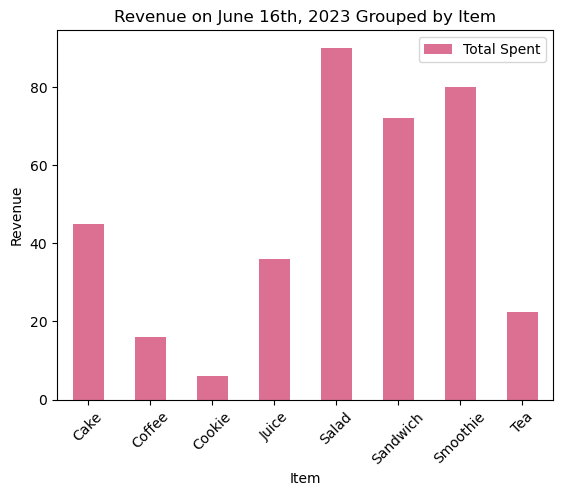

In [485]:
groupedPopular.plot(kind='bar', x='Item',y='Total Spent',color='palevioletred')
plt.xlabel('Item')
plt.ylabel('Revenue')
plt.title('Revenue on June 16th, 2023 Grouped by Item')
plt.xticks(rotation=45)
plt.show()

In [514]:
groupedPopularQuantity = popularJune.groupby('Item')['Quantity'].sum().reset_index()
groupedPopularQuantity

,Item,Quantity
0,Cake,15.0
1,Coffee,8.0
2,Cookie,6.0
3,Juice,12.0
4,Salad,18.0
5,Sandwich,18.0
6,Smoothie,20.0
7,Tea,15.0


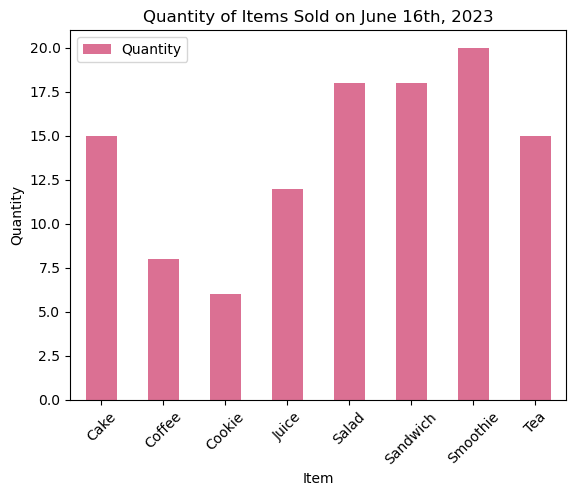

In [517]:
groupedPopularQuantity.plot(kind='bar', x='Item',y='Quantity',color='palevioletred')
plt.xlabel('Item')
plt.ylabel('Quantity')
plt.title('Quantity of Items Sold on June 16th, 2023')
plt.xticks(rotation=45)
plt.show()

On June 16 2023, the cafe generated the most revenue selling Salad, Sandwich, and Smoothies. The cafe generated the least revenue by selling Cookies, Coffee, and Tea. <br><br> The top performing items sold by quantity are also Salad, Sandwich, Smoothie. While the bottom performing items sold by quantity are Coffee, Cookie, and Juice.

#### Average Spending per Customer (Month, Day)

In [489]:
## customer spends on average ___ in a day grouped by month
avgSpendMonth = df.groupby('Month')['Total Spent'].mean().reset_index()
avgSpendMonth

,Month,Total Spent
0,1,8.900613
1,2,9.151515
2,3,8.736077
3,4,9.311284
4,5,8.979922
5,6,9.000000
6,7,8.716730
7,8,8.854557
8,9,8.741730
9,10,8.738351


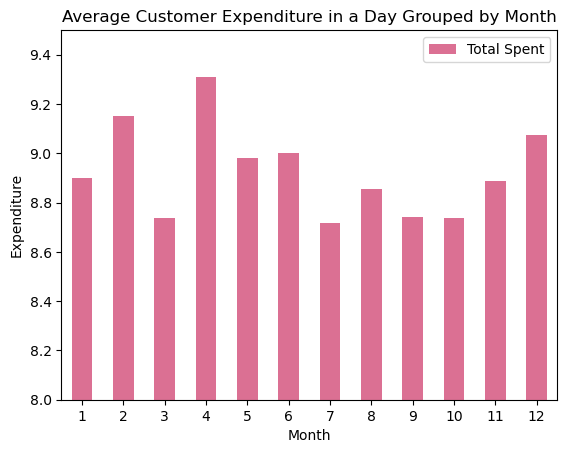

In [490]:
avgSpendMonth.plot(kind='bar', x='Month',y='Total Spent',color='palevioletred')
plt.xlabel('Month')
plt.ylabel('Expenditure')
plt.title('Average Customer Expenditure in a Day Grouped by Month')
plt.ylim(8,9.5)
plt.xticks(rotation=0)
plt.show()

Customers spent more on average in April (9.31) and less on average in June (8.72).

In [491]:
## average customer expenditure per day
avgSpendDay = round(df.groupby(['Month','Day'])['Total Spent'].mean().reset_index(),2)

In [492]:
expenditure_cross = avgSpendDay.pivot(index='Month', columns='Day', values='Total Spent').fillna(0)
expenditure_cross

Day,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
Month,,,,,,,,,,,,,,,,,,,,,
1,8.80,9.02,9.70,9.91,9.57,8.10,5.90,11.94,8.16,9.09,...,7.64,9.35,9.67,8.62,6.39,8.81,10.00,8.05,10.00,8.56
2,8.33,9.50,9.15,7.94,9.58,7.54,8.47,6.91,9.07,10.42,...,9.67,10.06,8.83,10.15,8.00,8.82,10.07,0.00,0.00,0.00
3,6.48,7.56,7.94,8.76,9.54,10.17,8.88,6.54,8.88,8.20,...,8.17,10.70,8.48,9.46,8.23,6.63,9.26,10.47,8.44,9.29
4,10.70,8.38,7.62,9.75,7.07,9.13,10.88,8.47,10.42,6.91,...,8.78,8.00,11.56,8.86,12.19,10.00,8.02,7.52,9.81,0.00
5,7.78,8.98,8.30,9.39,8.05,9.46,10.08,10.63,10.00,8.02,...,9.62,9.92,8.38,8.81,9.35,9.08,9.43,8.96,8.61,7.67
6,9.76,6.80,9.00,7.80,9.66,10.77,7.07,9.78,9.83,10.18,...,11.18,9.52,7.48,7.80,8.23,8.06,8.27,9.69,9.25,0.00
7,8.18,8.91,9.62,9.28,8.53,10.82,10.18,6.75,7.68,8.82,...,7.25,10.02,9.53,7.18,8.59,7.64,10.86,8.02,6.83,8.48
8,10.17,8.58,9.56,10.12,9.20,10.02,8.74,6.66,9.25,9.65,...,6.64,9.61,9.02,8.50,9.82,8.46,9.33,10.14,9.68,9.19
9,7.56,7.81,9.61,10.18,9.85,9.99,9.02,8.28,8.56,8.33,...,9.93,7.61,7.23,9.31,8.95,8.52,9.62,9.20,7.58,0.00


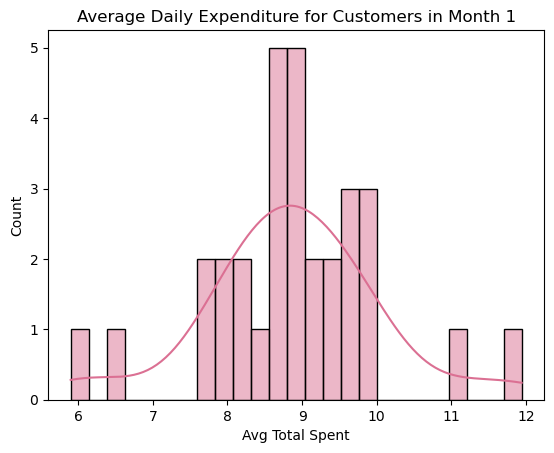

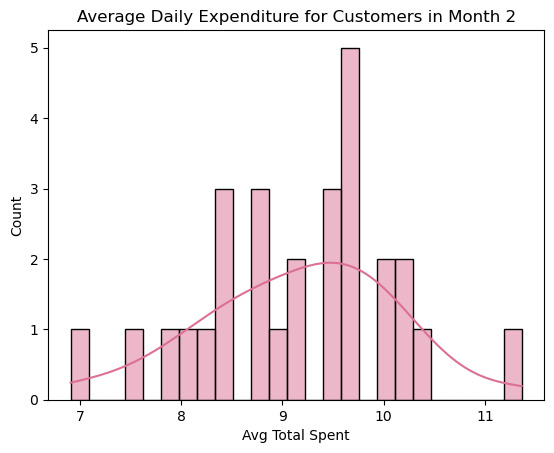

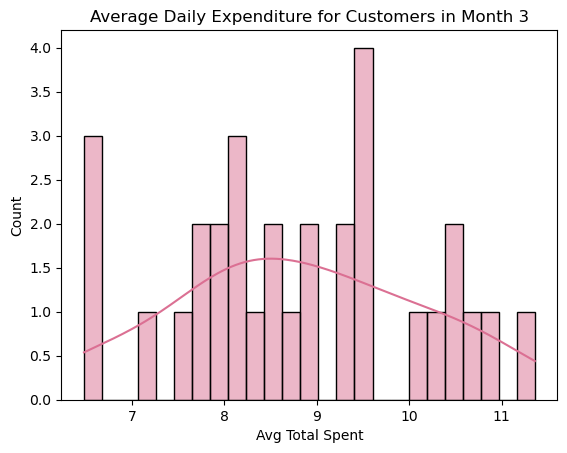

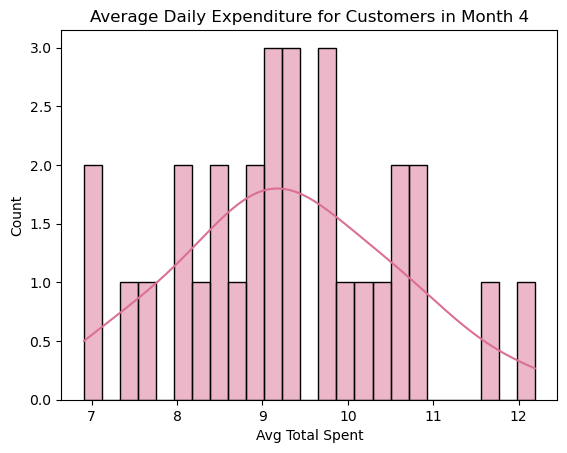

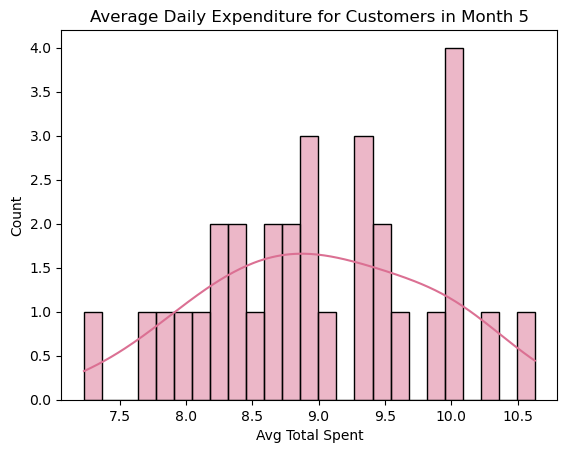

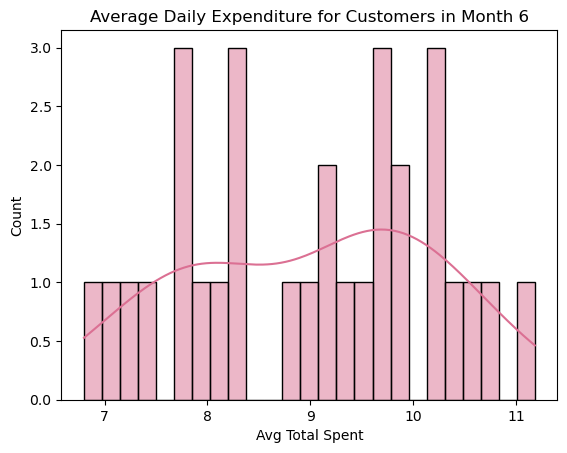

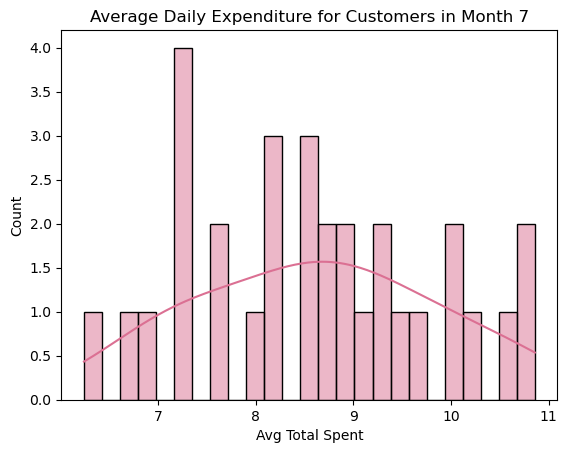

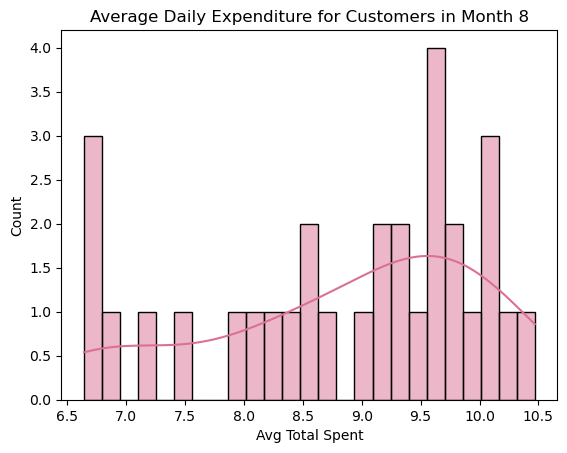

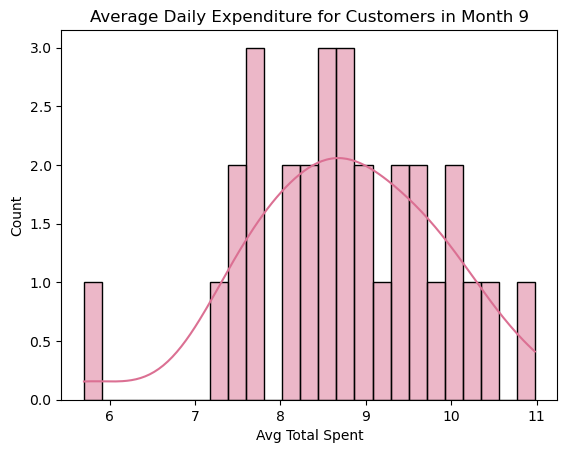

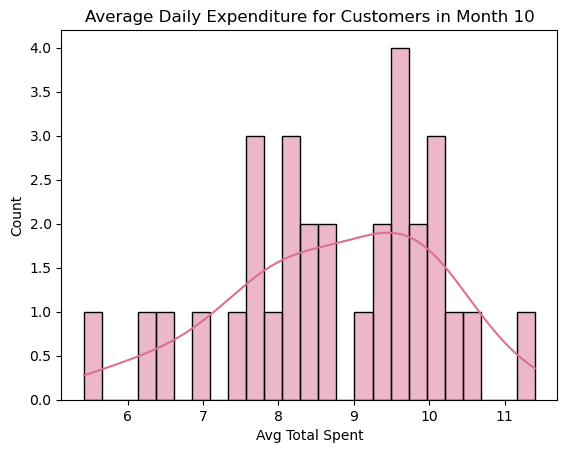

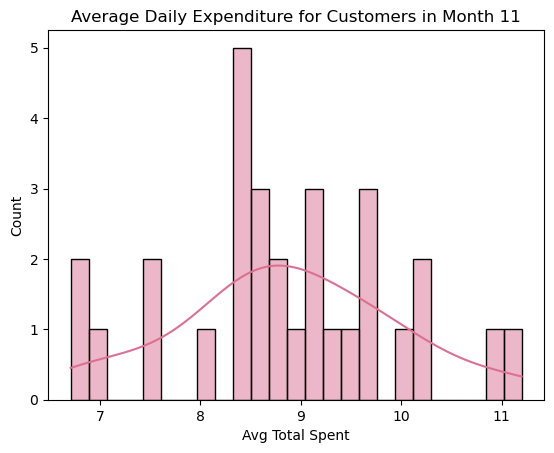

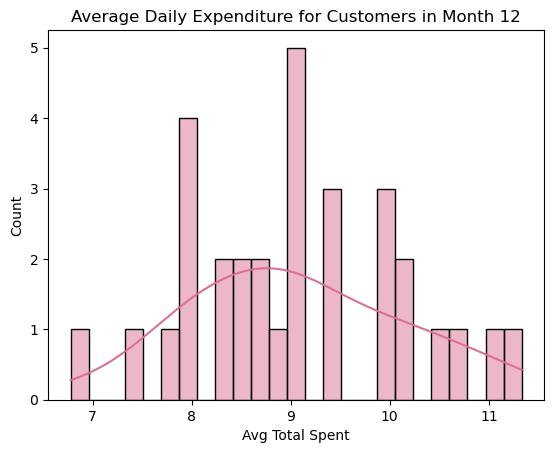

In [521]:
monthLabels = [1,2,3,4,5,6,7,8,9,10,11,12]

for label in monthLabels:
    subset = avgSpendDay[avgSpendDay['Month']==label]
    sns.histplot(subset['Total Spent'],kde=True, bins=25,color='palevioletred')
    plt.title(f'Average Daily Expenditure for Customers in Month {label}')
    plt.ylabel('Count')
    plt.xlabel('Avg Total Spent')
    plt.show()

Distribution of average expenditure per day for customers. Each histogram represents a month. The y axis is the count of customers that spent x amount on average during that month.

In [523]:
totalSpend_df = round(df.groupby(['Month','Day'])['Total Spent'].sum().reset_index(),2)
totalSpend_df

,Month,Day,Total Spent
0,1,1,176.0
1,1,2,189.5
2,1,3,194.0
3,1,4,267.5
4,1,5,363.5
...,...,...,...
360,12,27,225.0
361,12,28,175.0
362,12,29,169.5
363,12,30,210.0


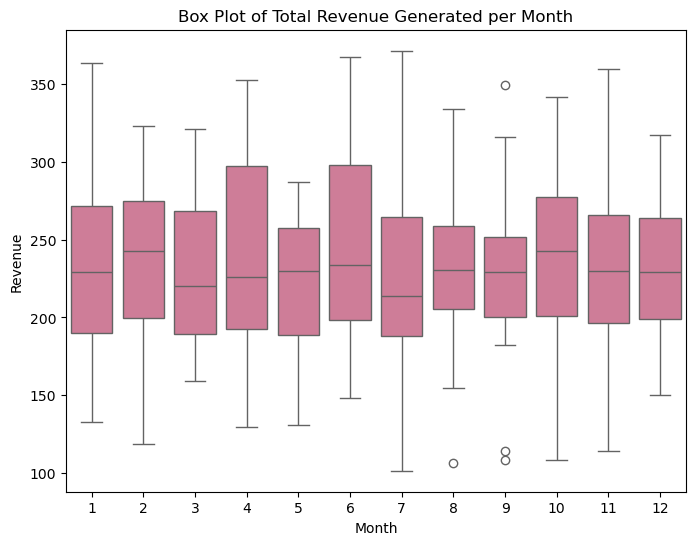

In [522]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Month',y='Total Spent', data=totalSpend_df, color='palevioletred')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.title('Box Plot of Total Revenue Generated per Month')
plt.show()

Distribution of revenue generated per month. Line in the middle is the median (Q2) 50% of data falls above and 50% of data falls below this line. Bottom edge is the Q1. 25% of the data falls below this point. Top edge is the Q3. 75% of the data falls below this point. Interquartile range spans from Q1 to Q3. Represents how tightly the data is clustered together. Whiskers represent the spread of the lower 25% and upper 25%. Any points are considered outliers.

In [496]:
highestSpentPerDay = totalSpend_df['Total Spent'].max()
lowestSpentPerDay = totalSpend_df['Total Spent'].min()
avgSpentPerDay = round(totalSpend_df['Total Spent'].mean(),2)
avgCustomerSpentPerDay = round(avgSpendDay['Total Spent'].mean(),2)


print('Largest Revenue Day: ', highestSpentPerDay, 
      '\nLowest Revenue Day: ', lowestSpentPerDay, 
      '\nAverage Revenue: ', avgSpentPerDay, ' per Day',
     '\n\nAverage Customer Spent: ', avgCustomerSpentPerDay, ' per Day')

Largest Revenue Day:  371.5 
Lowest Revenue Day:  101.5 
Average Revenue:  232.52  per Day 

Average Customer Spent:  8.92  per Day


#### Most Popular Days of the Week

In [497]:
## map datetime to days of the week
df['Weekday'] = df['Transaction Date'].dt.strftime('%A')

In [525]:
weekdayRevenue = df.groupby(['Month','Weekday'])['Total Spent'].sum().reset_index()
weekdayRevenue.head(10)

,Month,Weekday,Total Spent
0,1,Friday,920.5
1,1,Monday,1179.0
2,1,Saturday,937.5
3,1,Sunday,1145.0
4,1,Thursday,982.0
5,1,Tuesday,1122.0
6,1,Wednesday,968.0
7,2,Friday,927.5
8,2,Monday,1039.0
9,2,Saturday,1014.5


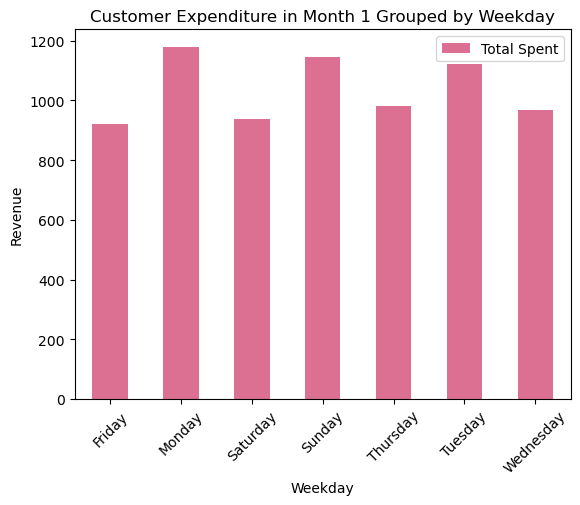

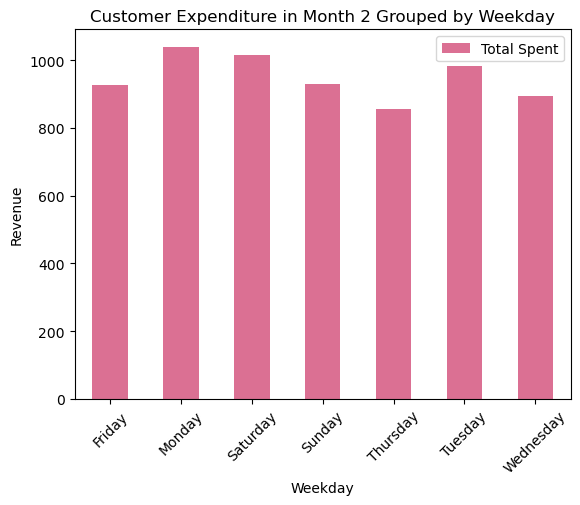

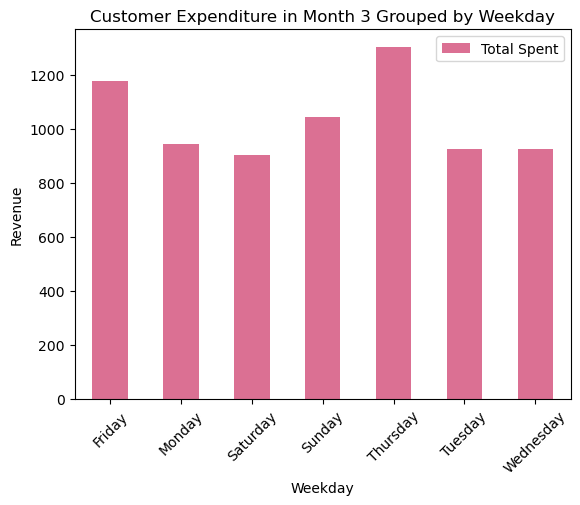

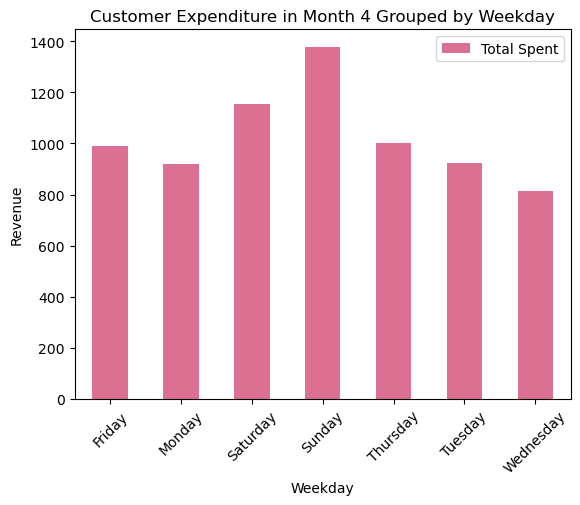

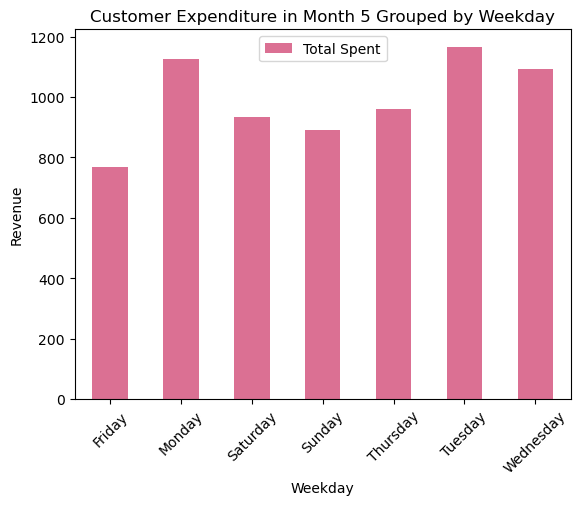

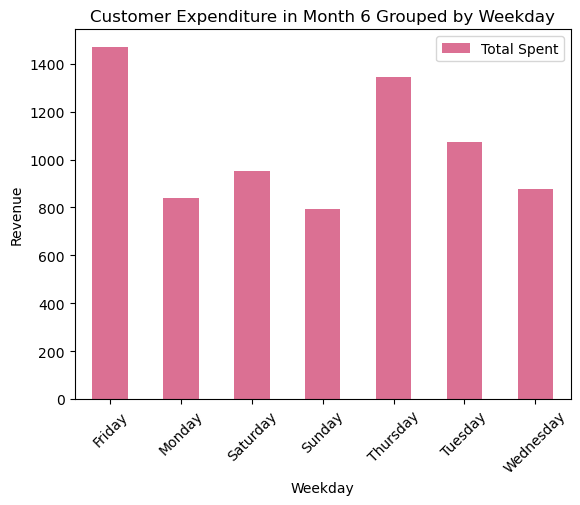

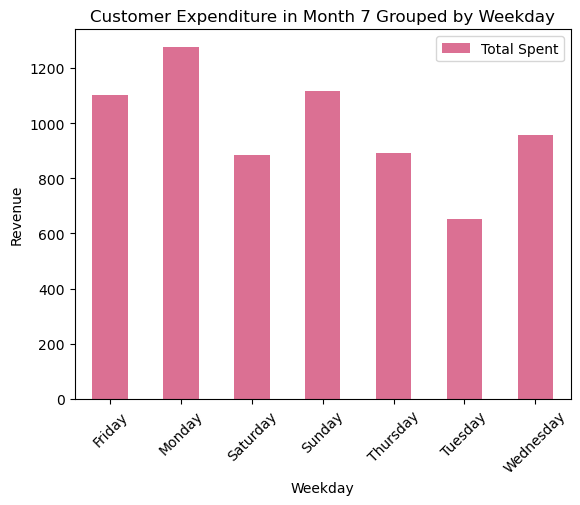

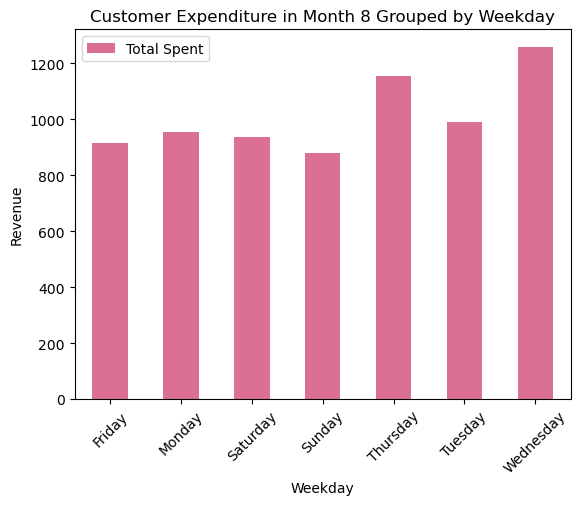

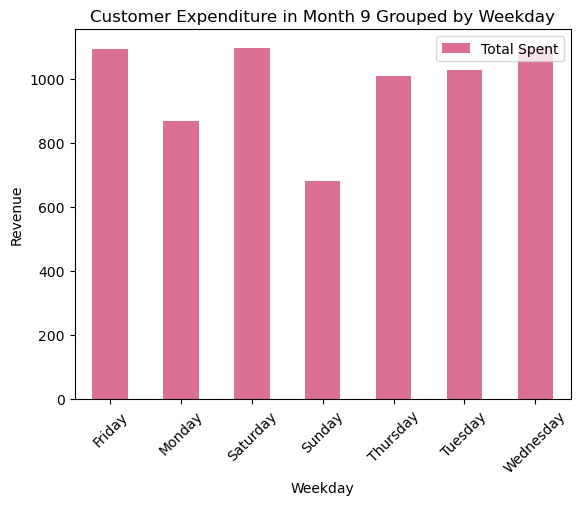

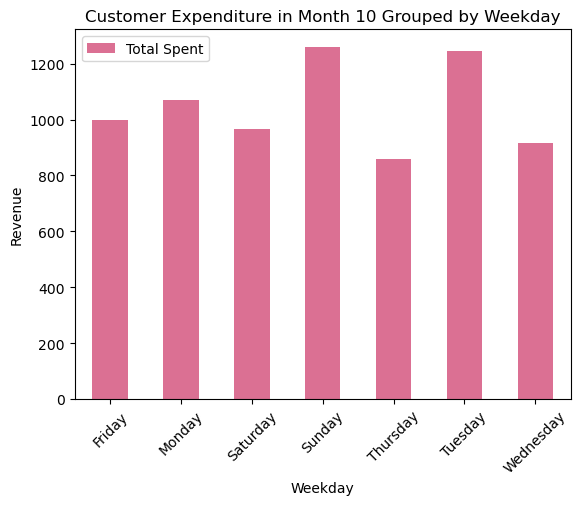

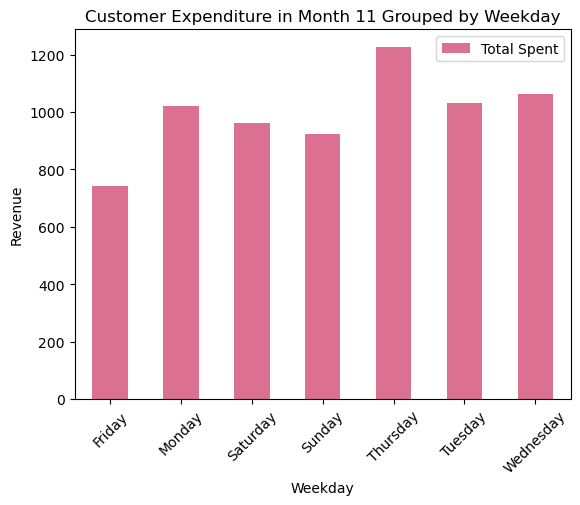

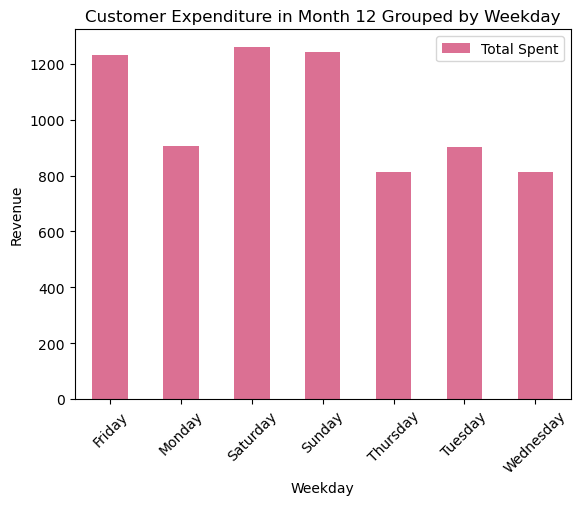

In [527]:
monthLabels = [1,2,3,4,5,6,7,8,9,10,11,12]

for label in monthLabels:
    subset = weekdayRevenue[weekdayRevenue['Month']==label]
    subset.plot(kind='bar', x='Weekday',y='Total Spent',color='palevioletred')
    plt.xlabel('Weekday')
    plt.ylabel('Revenue')
    plt.title(f'Customer Expenditure in Month {label} Grouped by Weekday')
    plt.xticks(rotation=45)
    plt.show()

In [529]:
weekdayRevenueTotal = df.groupby('Weekday')['Total Spent'].sum().reset_index()
weekdayRevenueTotal.head(10)

,Weekday,Total Spent
0,Friday,12334.0
1,Monday,12140.0
2,Saturday,11994.5
3,Sunday,12287.5
4,Thursday,12401.5
5,Tuesday,12039.5
6,Wednesday,11671.5


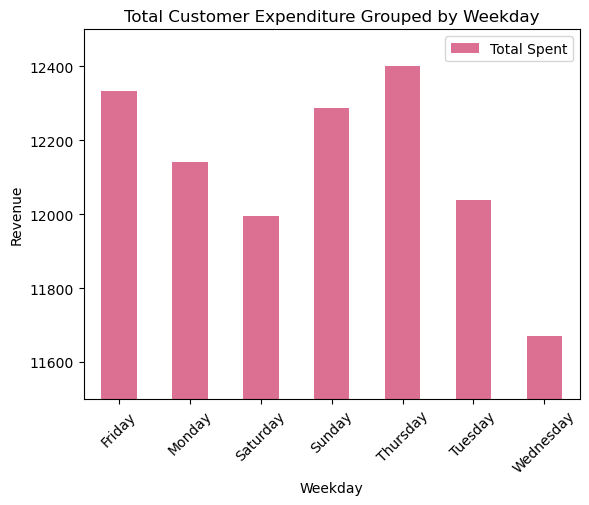

In [531]:
weekdayRevenueTotal.plot(kind='bar', x='Weekday',y='Total Spent',color='palevioletred')
plt.xlabel('Weekday')
plt.ylabel('Revenue')
plt.title('Total Customer Expenditure Grouped by Weekday')
plt.ylim(11500,12500)
plt.xticks(rotation=45)
plt.show()

While not immediately obvious from looking at each individual months revenue. The days of the week the most money was generated were Thursday, Friday, and Sunday. 

#### Rvenue of Items per Month (Line plots)

In [532]:
## How much revenue each item brings in each month (does popularity wane or rise throughout the year?)
revenueItemsMonth = round(df.groupby(['Item','Month'])['Total Spent'].sum().reset_index(),2)
revenueItemsMonth

,Item,Month,Total Spent
0,Cake,1,915.0
1,Cake,2,807.0
2,Cake,3,906.0
3,Cake,4,975.0
4,Cake,5,927.0
...,...,...,...
91,Tea,8,475.5
92,Tea,9,450.0
93,Tea,10,522.0
94,Tea,11,369.0


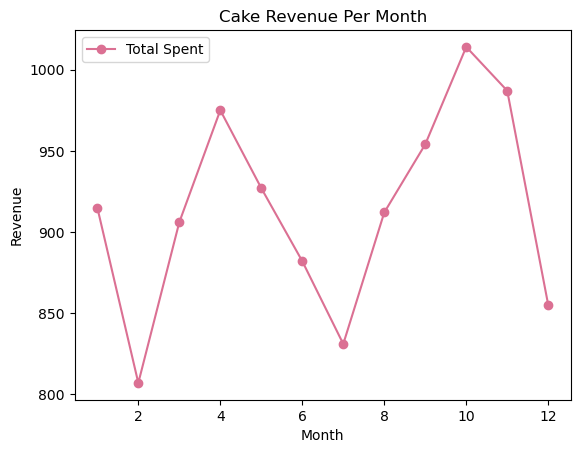

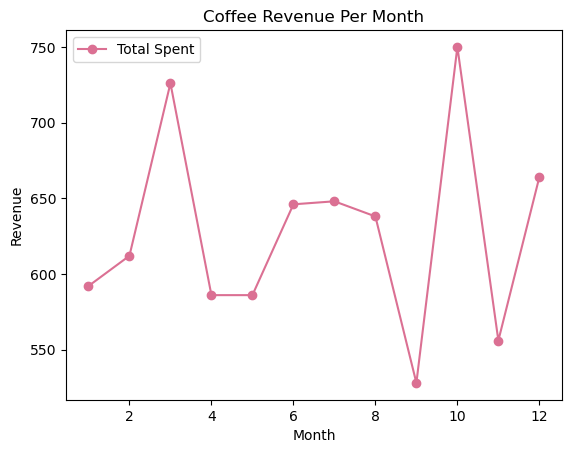

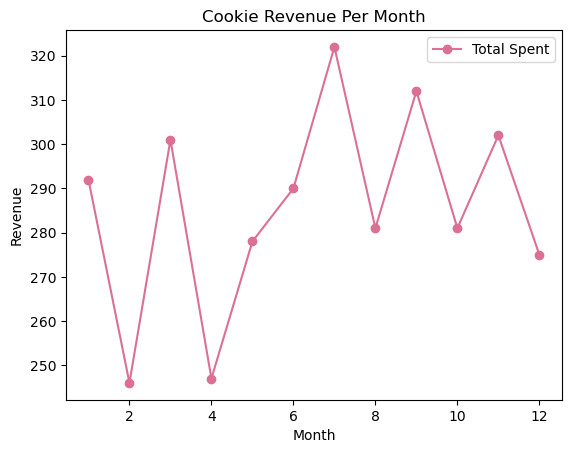

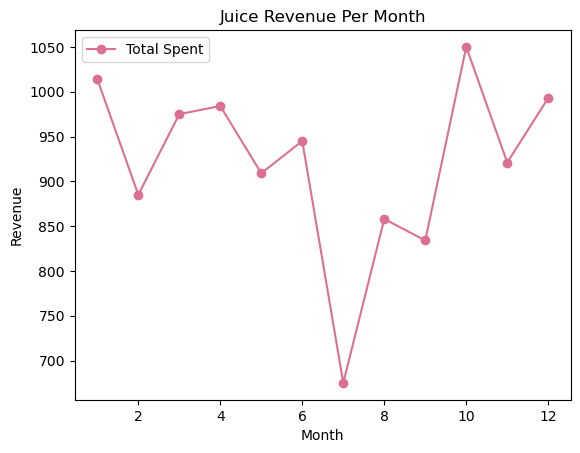

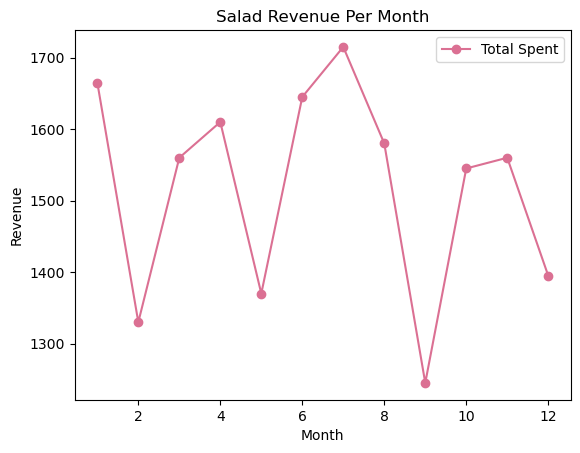

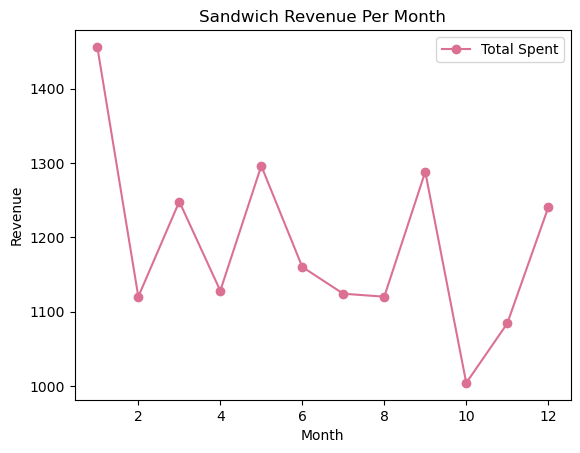

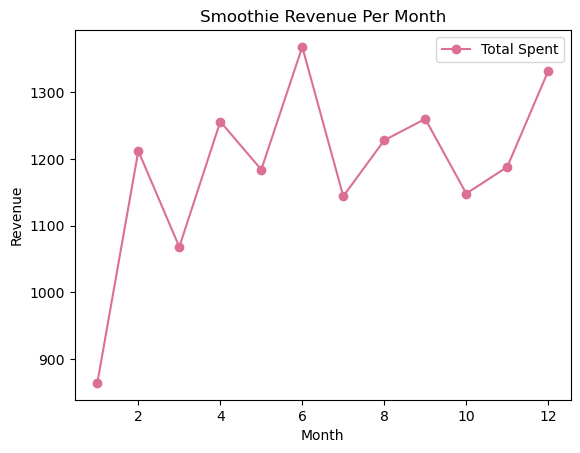

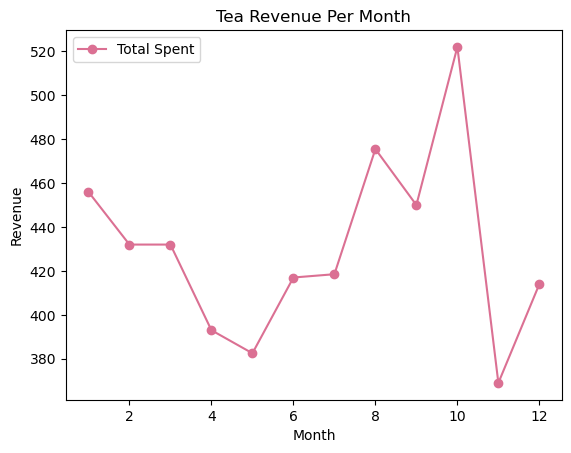

In [508]:
itemLabels = ['Cake', 'Coffee', 'Cookie','Juice','Salad','Sandwich','Smoothie','Tea']

for label in itemLabels:
    subset = revenueItemsMonth[revenueItemsMonth['Item']==label]
    subset.plot(kind='line',marker='o', color='palevioletred', x='Month', y='Total Spent')
    plt.title(f'{label} Revenue Per Month')
    plt.ylabel('Revenue')
    plt.xlabel('Month')
    plt.show()

<b>Best Performing Month vs Worst Performing Month</b><br>
Cake: Oct vs Feb <br>
Coffee: Oct vs Sept <br>
Cookie: Jul vs Feb <br>
Juice: Oct vs Jul <br>
Salad: Jul vs Sept <br>
Sandwich: Jan vs Oct <br>
Smoothie: Jun vs Jan <br>
Tea: Oct vs Nov <br>

1/4 of Items had their best month in October. The worst month was between Feb/Sept for 1/3 of the Items.

#### Dine-In vs Take-out

In [509]:
locationSpending = df.groupby('Location')['Total Spent'].count().reset_index()
locationSpending

,Location,Total Spent
0,In-store,2861
1,Takeaway,6653


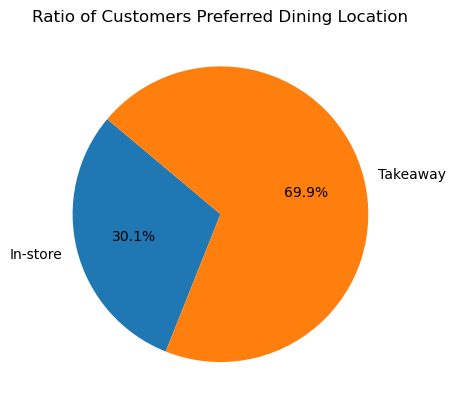

In [510]:
plt.pie(locationSpending['Total Spent'], labels=locationSpending['Location'].values, autopct='%1.1f%%', startangle=140)
plt.title('Ratio of Customers Preferred Dining Location')
plt.show()

Most customers prefer takeaway than eating in-store.

#### Preferred Payment Method

In [511]:
paymentSpending = df.groupby('Payment Method')['Total Spent'].count().reset_index()
paymentSpending

,Payment Method,Total Spent
0,Cash,2154
1,Credit Card,2165
2,Digital Wallet,5195


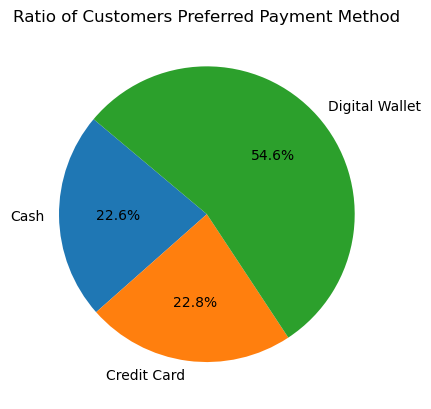

In [512]:
plt.pie(paymentSpending['Total Spent'], labels=paymentSpending['Payment Method'].values, autopct='%1.1f%%', startangle=140)
plt.title('Ratio of Customers Preferred Payment Method')
plt.show()

Most customers prefer using their digital wallet.

## Conclusion and Next Steps

Coffee and Juice were some of the best performing items by quantity, but not by Revenue. Simple solution to generate more revenue would be to increase price of these items since sales are guaranteed. Tea and Cookie were consistently in the bottom three; either decrease price to motivate customers to buy, market items better with promotions or deals, or remove from menu (cost of producing might be higher than the revenue generated).

For lower performing months like February, July, Sept, May; consider adding promotions to the cafe to generate a greater flux of customers. Likely paring top selling items of the month (Coffee in October, Sandwiches in January) with lower selling items in a special promotion.

On average, customers aim to spend between 5 and up to 12 dollars at this cafe. Make sure to keep item prices inside of a comfortable customer spending limit. Find the months where the ditrubition of customers are inclined to spend more (APR) and offer promotions to motivate spending. On the other hand, find months where customers are inclined to spend less (MAR) and offer discounts and deals to provide an illusion of saving more but spending less; thus generating more profit for the cafe.

Popular days of the week differ by month; in general the most revenue was generated by Thursdays, Sundays, and Fridays. Provide weekday specials and coupons. Market/Promote items that generate more revenue in certain months (like Cake in October). If necessary, make the product a seasonal item; scarcity generates more sales. (Cookies preform better in the second half of the year).

Finally, make sure to run maintenance on digital systems frequently and ensure everything is in proper working order as most transactions deal with digital wallets or credit cards. We don't want to lose customers because certain systems are down and we can only accept cash.

##

In [ ]:
## download cleaned data

In [539]:
df.to_csv('Clean_CafeSalesData.csv',index=False)

In [ ]:
## June Data Only

In [541]:
juneDf = df[df['Month']==6]
juneDf.to_csv('CleanJune_CafeSalesData.csv',index=False)